# Dashboard de Monitorización de Modelos ML
### TFM — Máster en IA, Big Data & Cloud | Management Solutions

**Dataset:** Credit Card Fraud Detection  
Coloca `creditcard.csv` en la misma carpeta que este notebook y ejecuta celda a celda.

---

## 0. Instalación de dependencias

In [1]:
# Descomenta y ejecuta si no tienes alguna librería instalada
# !pip install pandas numpy scikit-learn shap matplotlib seaborn scipy

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, RocCurveDisplay
)
from scipy.stats import ks_2samp
import shap
shap.initjs()

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas')

Librerías cargadas


---
## 2. Carga de datos

In [3]:
df = pd.read_csv('creditcard.csv')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}  |  Nulos: {df.isnull().sum().sum()}')
df.head()

Filas: 284,807  |  Columnas: 31  |  Nulos: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. EDA — Análisis Exploratorio

Legítimas  (0): 284,315  (99.83%)
Fraudes    (1): 492  (0.17%)


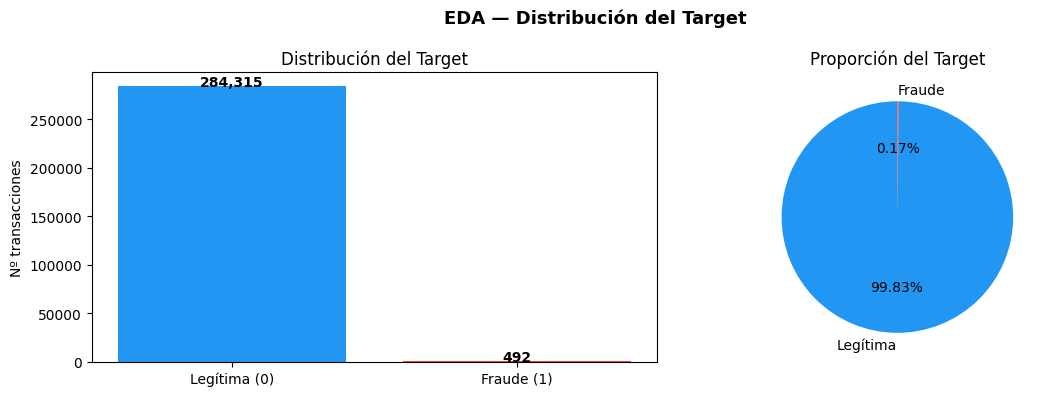

In [4]:
# Distribución del target
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print(f'Legítimas  (0): {class_counts[0]:,}  ({class_pct[0]:.2f}%)')
print(f'Fraudes    (1): {class_counts[1]:,}  ({class_pct[1]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Distribución del Target')
axes[0].set_ylabel('Nº transacciones')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legítima', 'Fraude'],
            colors=['#2196F3', '#F44336'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Proporción del Target')

plt.suptitle('EDA — Distribución del Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

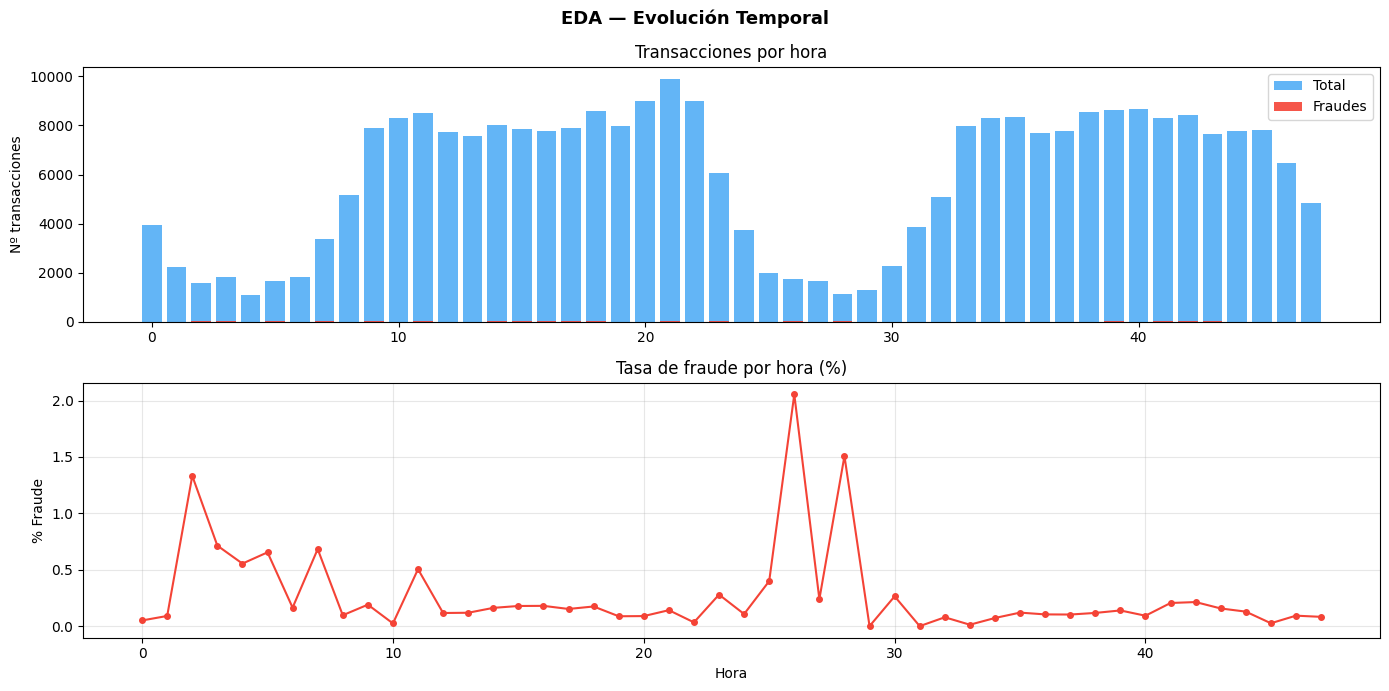

In [5]:
# Evolución temporal del fraude
df['hour'] = (df['Time'] // 3600).astype(int)
fraud_by_hour = df.groupby('hour')['Class'].agg(['sum', 'count'])
fraud_by_hour['fraud_rate'] = fraud_by_hour['sum'] / fraud_by_hour['count'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].bar(fraud_by_hour.index, fraud_by_hour['count'], color='#2196F3', alpha=0.7, label='Total')
axes[0].bar(fraud_by_hour.index, fraud_by_hour['sum'],   color='#F44336', alpha=0.9, label='Fraudes')
axes[0].set_title('Transacciones por hora')
axes[0].set_ylabel('Nº transacciones')
axes[0].legend()

axes[1].plot(fraud_by_hour.index, fraud_by_hour['fraud_rate'], color='#F44336', marker='o', markersize=4)
axes[1].set_title('Tasa de fraude por hora (%)')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('% Fraude')
axes[1].grid(True, alpha=0.3)

plt.suptitle('EDA — Evolución Temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

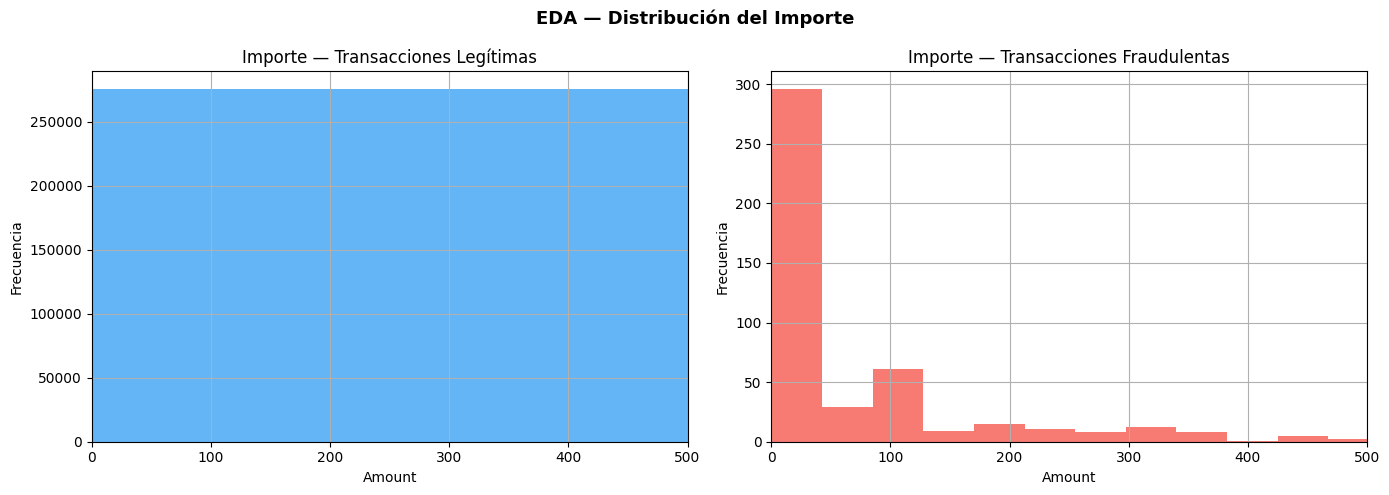

Importe medio legítimas:    88.29
Importe medio fraudulentas: 122.21


In [6]:
# Distribución del importe por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='#2196F3', alpha=0.7)
axes[0].set_title('Importe — Transacciones Legítimas')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 500)

df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='#F44336', alpha=0.7)
axes[1].set_title('Importe — Transacciones Fraudulentas')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 500)

plt.suptitle('EDA — Distribución del Importe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Importe medio legítimas:    {df[df["Class"]==0]["Amount"].mean():.2f}')
print(f'Importe medio fraudulentas: {df[df["Class"]==1]["Amount"].mean():.2f}')

---
## 4. Preprocesamiento

Split **temporal** 70/30: los datos más antiguos se usan para entrenar, los más recientes simulan producción.

In [7]:
df_sorted = df.sort_values('Time').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.70)
train_df  = df_sorted.iloc[:split_idx].copy()
test_df   = df_sorted.iloc[split_idx:].copy()

print(f'Train: {len(train_df):,} filas | Fraudes: {train_df["Class"].sum()} ({train_df["Class"].mean()*100:.2f}%)')
print(f'Test:  {len(test_df):,}  filas | Fraudes: {test_df["Class"].sum()} ({test_df["Class"].mean()*100:.2f}%)')

FEATURES = [c for c in df.columns if c not in ['Class', 'Time', 'hour']]

X_train = train_df[FEATURES].copy()
y_train = train_df['Class']
X_test  = test_df[FEATURES].copy()
y_test  = test_df['Class']

# Escalar Amount (V1-V28 ya vienen normalizadas por PCA)
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])

print(f'\nFeatures: {FEATURES}')

Train: 199,364 filas | Fraudes: 384 (0.19%)
Test:  85,443  filas | Fraudes: 108 (0.13%)

Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


---
## 5. Entrenamiento del Modelo

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',   # compensa el desbalanceo 0.17% fraudes
    random_state=SEED,
    n_jobs=-1
)

print('Entrenando...')
model.fit(X_train, y_train)
print('Modelo entrenado')

Entrenando...
Modelo entrenado


---
## 6. Métricas de Rendimiento

In [9]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('=== MÉTRICAS DE RENDIMIENTO ===')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

=== MÉTRICAS DE RENDIMIENTO ===
  Accuracy : 0.9995
  Precision: 0.8557
  Recall   : 0.7685
  F1-Score : 0.8098
  ROC-AUC  : 0.9831

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     85335
      Fraude       0.86      0.77      0.81       108

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



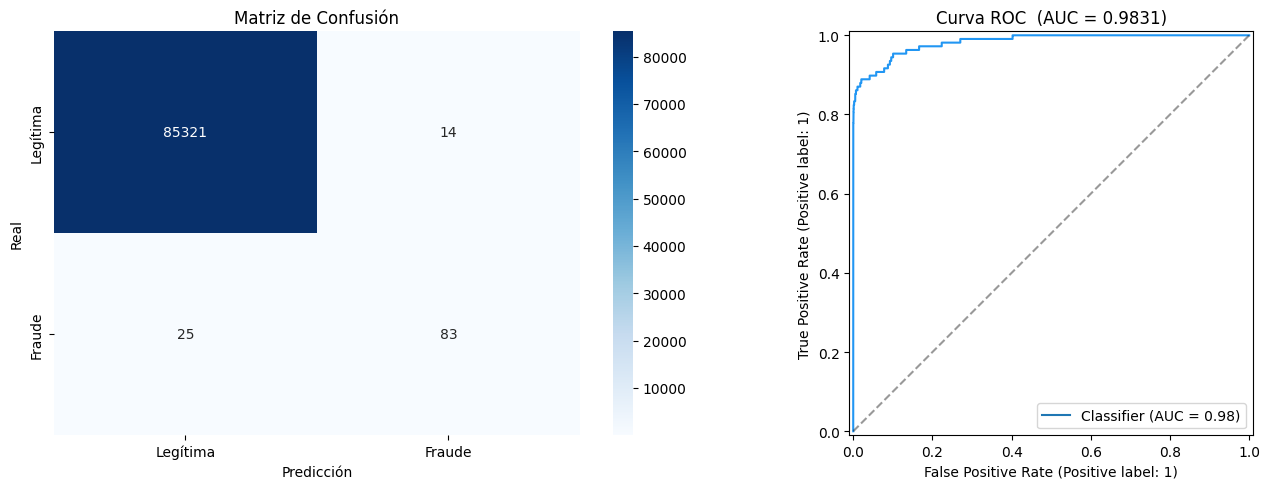

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Curva ROC
auc = roc_auc_score(y_test, y_pred_proba)
disp = RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
disp.line_.set_color('#2196F3')
axes[1].set_title(f'Curva ROC  (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 7. Detección de Data Drift

Dividimos el test en dos ventanas temporales y comparamos las distribuciones de cada feature con el **test KS (Kolmogorov-Smirnov)**.
- `p-value < 0.05` → drift detectado en esa feature
- `KS statistic` → magnitud del drift

In [13]:
mid      = len(test_df) // 2
window_1 = X_test.iloc[:mid]   # más antigua — referencia
window_2 = X_test.iloc[mid:]   # más reciente — producción

drift_results = []
for col in FEATURES:
    ks_stat, p_value = ks_2samp(window_1[col], window_2[col])
    drift_results.append({
        'feature':        col,
        'ks_statistic':   round(ks_stat, 4),
        'p_value':        round(p_value, 4),
        'drift_detected': p_value < 0.05
    })

drift_df = pd.DataFrame(drift_results).sort_values('ks_statistic', ascending=False)
n_drift  = drift_df['drift_detected'].sum()

print(f'Features con drift detectado: {n_drift} / {len(FEATURES)}')
print()
drift_df.style.apply(
    lambda col: ['background-color: #ffcccc' if v else '' for v in col],
    subset=['drift_detected']
)

Features con drift detectado: 28 / 29



,feature,ks_statistic,p_value,drift_detected
28,Amount,0.082400,0.000000,True
1,V2,0.052700,0.000000,True
20,V21,0.051100,0.000000,True
21,V22,0.045400,0.000000,True
11,V12,0.040200,0.000000,True
24,V25,0.038000,0.000000,True
12,V13,0.036000,0.000000,True
9,V10,0.035500,0.000000,True
5,V6,0.031000,0.000000,True
26,V27,0.031000,0.000000,True


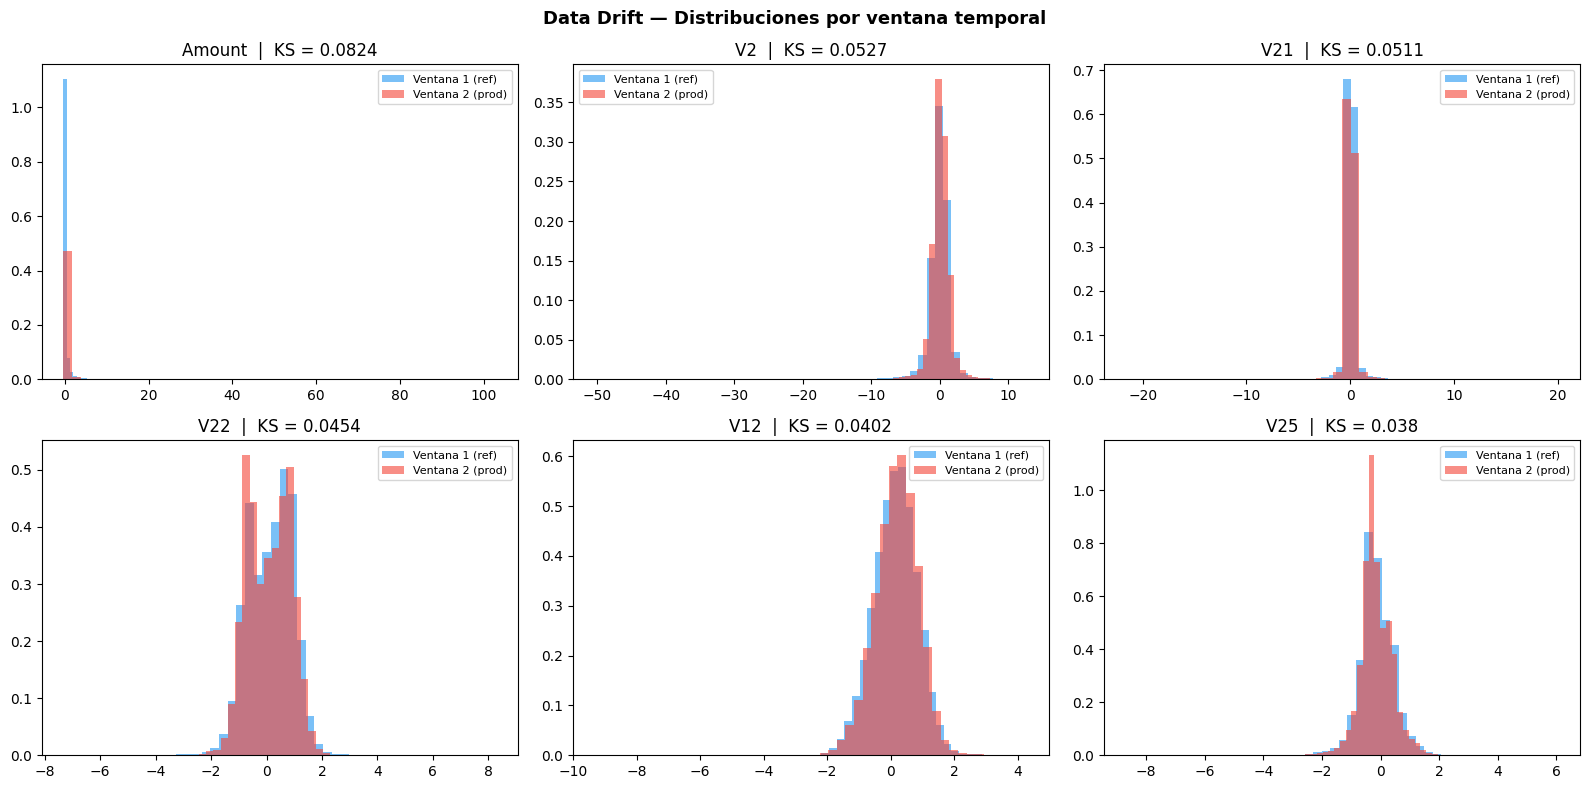

In [14]:
# Distribuciones de las features con más drift
top_drift = drift_df[drift_df['drift_detected']].head(6)['feature'].tolist()

if top_drift:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, feat in enumerate(top_drift):
        axes[i].hist(window_1[feat], bins=50, alpha=0.6, color='#2196F3', label='Ventana 1 (ref)', density=True)
        axes[i].hist(window_2[feat], bins=50, alpha=0.6, color='#F44336', label='Ventana 2 (prod)', density=True)
        ks = drift_df[drift_df['feature'] == feat]['ks_statistic'].values[0]
        axes[i].set_title(f'{feat}  |  KS = {ks}')
        axes[i].legend(fontsize=8)
    for j in range(len(top_drift), 6):
        axes[j].set_visible(False)
    plt.suptitle('Data Drift — Distribuciones por ventana temporal', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No se detectó drift significativo entre las dos ventanas.')

=== CONCEPT DRIFT — Comparativa de métricas ===
Métrica      Ventana 1   Ventana 2         Δ
--------------------------------------------
F1              0.8627      0.7573   -0.1054  ↓ BAJA
Recall          0.7857      0.7500   -0.0357  ↓ BAJA
ROC-AUC         0.9853      0.9810   -0.0043  → ESTABLE


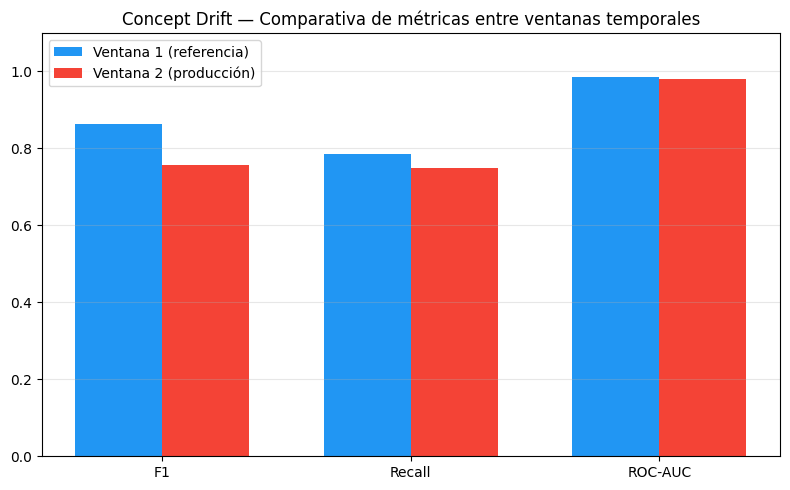

In [15]:
# Concept Drift: ¿bajan las métricas del modelo en la segunda ventana?
y_w1 = y_test.iloc[:mid]
y_w2 = y_test.iloc[mid:]

def get_metrics(y_true, y_pred_bin, y_proba):
    return {
        'F1':      round(f1_score(y_true, y_pred_bin, zero_division=0), 4),
        'Recall':  round(recall_score(y_true, y_pred_bin, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_proba) if y_true.sum() > 0 else 0, 4)
    }

m1 = get_metrics(y_w1, model.predict(window_1), model.predict_proba(window_1)[:, 1])
m2 = get_metrics(y_w2, model.predict(window_2), model.predict_proba(window_2)[:, 1])

print('=== CONCEPT DRIFT — Comparativa de métricas ===')
print(f'{"Métrica":10s}  {"Ventana 1":>10s}  {"Ventana 2":>10s}  {"Δ":>8s}')
print('-' * 44)
for k in m1:
    delta = m2[k] - m1[k]
    trend = '↓ BAJA' if delta < -0.02 else ('↑ SUBE' if delta > 0.02 else '→ ESTABLE')
    print(f'{k:10s}  {m1[k]:>10.4f}  {m2[k]:>10.4f}  {delta:>+8.4f}  {trend}')

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(m1))
w = 0.35
ax.bar(x - w/2, list(m1.values()), w, label='Ventana 1 (referencia)', color='#2196F3')
ax.bar(x + w/2, list(m2.values()), w, label='Ventana 2 (producción)', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(list(m1.keys()))
ax.set_ylim(0, 1.1)
ax.set_title('Concept Drift — Comparativa de métricas entre ventanas temporales')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Interpretabilidad con SHAP

SHAP explica qué features empujan el modelo hacia "fraude" o "legítima", tanto a nivel global como por transacción individual.

In [16]:
print('Calculando SHAP values (puede tardar 1-2 min)...')
X_sample    = X_test.sample(n=min(2000, len(X_test)), random_state=SEED)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
shap_fraud  = shap_values[1] if isinstance(shap_values, list) else shap_values
print('Listo')

Calculando SHAP values (puede tardar 1-2 min)...
Listo


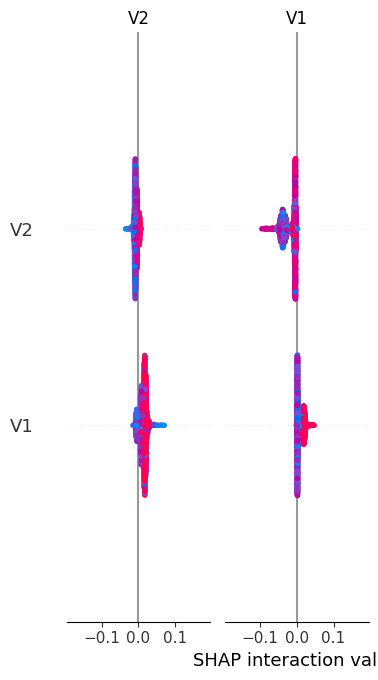

In [17]:
# Importancia global de features (barras)
shap.summary_plot(shap_fraud, X_sample, plot_type='bar')

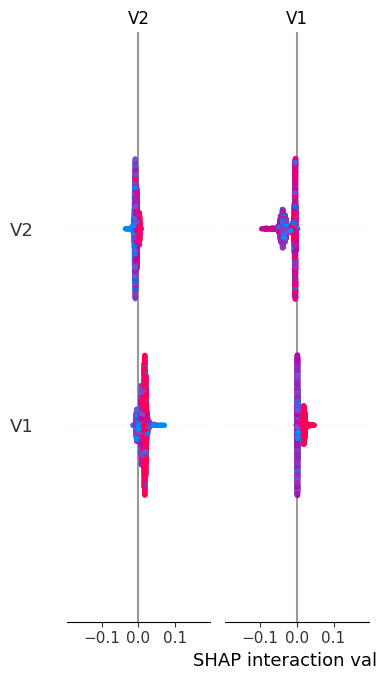

In [18]:
# Distribución del impacto por feature (beeswarm)
shap.summary_plot(shap_fraud, X_sample)

Transacción 254344 — Probabilidad de fraude: 0.0539


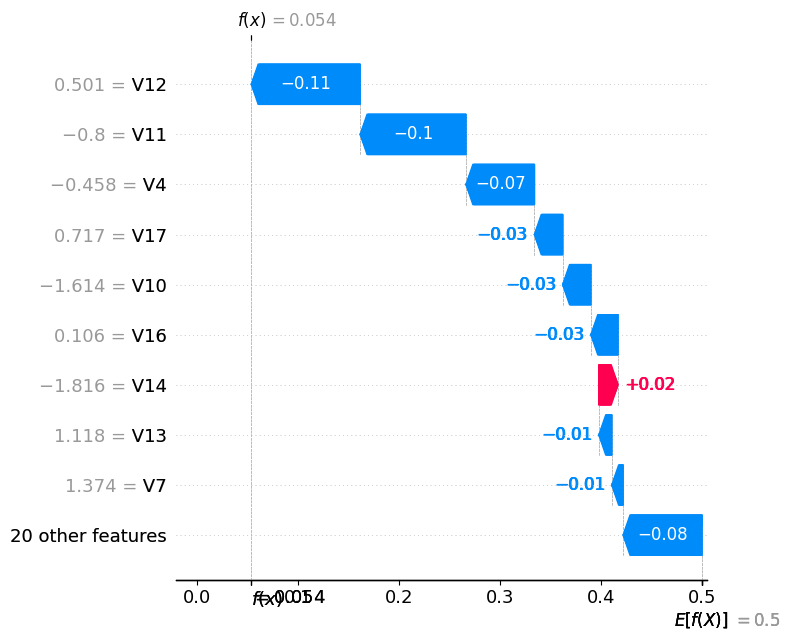

In [24]:
import os

# Explicación individual de una transacción fraudulenta
y_sample  = y_test.loc[X_sample.index]
fraud_idx = y_sample[y_sample == 1].index

if len(fraud_idx) > 0:
    idx        = fraud_idx[0]
    sample_pos = X_sample.index.get_loc(idx)
    prob       = model.predict_proba(X_sample.loc[[idx]])[0][1]

    ev       = explainer.expected_value
    base_val = float(ev[1]) if hasattr(ev, '__len__') and len(ev) > 1 else float(ev)

    print(f'Transacción {idx} — Probabilidad de fraude: {prob:.4f}')

    sv = shap_fraud[sample_pos]
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[:, 1] if sv.ndim == 2 else sv,
            base_values=base_val,
            data=X_sample.iloc[sample_pos].values,
            feature_names=FEATURES
        ),
        show=False
    )
    plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    plt.savefig('plots/shap_individual_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('No hay fraudes en la muestra.')

